## 1. Dataset Loading and Initial Inspection

The dataset was loaded using Pandas and initially inspected to understand its structure, size, column names, data types, and missing values. The first five records were displayed to get an overview of the available features.


In [56]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/dataset_12000_records.csv")

# Display the first 5 rows
df.head()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Columns in the dataset:")
print(df.columns.tolist())
df.info()
print("Missing values:")
print(df.isnull().sum())

Number of rows: 12000
Number of columns: 36
Columns in the dataset:
['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke', 'Atrial_Fibrillation', 'Previous_HF_Admissions', 'Previous_Hospital_Admissions', 'Heart_Failure_Type', 'NYHA_Class', 'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission', 'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic', 'SGLT2_Inhibitor', 'Readmitted_30_Days']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12000 non-null  object 
 1   Age                   

## 2. Target Variable Analysis

The target variable Readmitted_30_Days was analyzed to understand the distribution of patients who were and were not readmitted within 30 days.

##     2.1 Target Variable Distribution

The distribution of the target variable was examined using value counts and percentages. A bar chart was also created to visualize the proportion of patients who were and were not readmitted within 30 days.

Readmitted_30_Days value counts:
Readmitted_30_Days
0    8400
1    3600
Name: count, dtype: int64

Readmitted_30_Days percentage:
Readmitted_30_Days
0    70.0
1    30.0
Name: proportion, dtype: float64


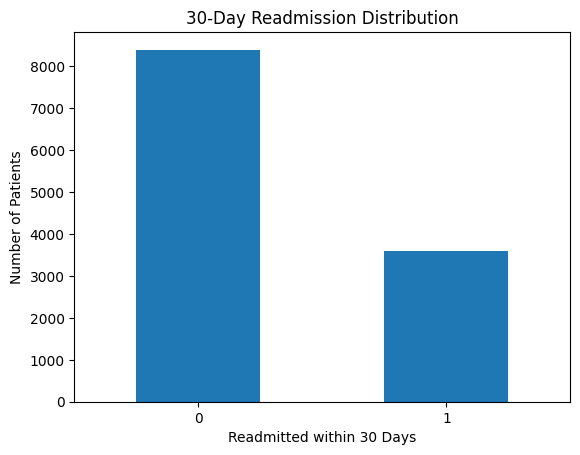

In [57]:
# Check the target variable distribution

print("Readmitted_30_Days value counts:")
print(df["Readmitted_30_Days"].value_counts())

print("\nReadmitted_30_Days percentage:")
print(df["Readmitted_30_Days"].value_counts(normalize=True) * 100)
# Visualize the target distribution

import matplotlib.pyplot as plt

df["Readmitted_30_Days"].value_counts().plot(kind="bar")

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

## 3. Exploratory Data Analysis

## 3.1 Descriptive Statistics

Descriptive statistics were calculated for the numerical features to understand their distributions, central tendency, and ranges.

In [58]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12000.0,67.396417,13.079380,30.000000,60.000000,68.000000,77.000000,95.000000
BMI,12000.0,27.790903,5.035375,16.000000,24.299963,27.780840,31.246772,45.975566
Exercise_Frequency,12000.0,1.018583,1.036819,0.000000,0.000000,1.000000,2.000000,4.000000
Hypertension,12000.0,0.412417,0.492290,0.000000,0.000000,0.000000,1.000000,1.000000
Diabetes,12000.0,0.296667,0.456807,0.000000,0.000000,0.000000,1.000000,1.000000
Chronic_Kidney_Disease,12000.0,0.268000,0.442936,0.000000,0.000000,0.000000,1.000000,1.000000
Coronary_Artery_Disease,12000.0,0.401500,0.490222,0.000000,0.000000,0.000000,1.000000,1.000000
Previous_Stroke,12000.0,0.183083,0.386751,0.000000,0.000000,0.000000,0.000000,1.000000
Atrial_Fibrillation,12000.0,0.277333,0.447701,0.000000,0.000000,0.000000,1.000000,1.000000
Previous_HF_Admissions,12000.0,0.631083,0.874765,0.000000,0.000000,0.000000,1.000000,7.000000


## 3.2 Categorical Feature Inspection

The unique values and frequency counts of categorical features were examined to understand the categories present in the dataset and identify any unexpected values.

In [59]:
# Check unique values and frequency counts for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Patient_ID
Patient_ID
PT_11984    1
PT_11983    1
PT_11982    1
PT_11981    1
PT_11980    1
           ..
PT_00005    1
PT_00004    1
PT_00003    1
PT_00002    1
PT_00001    1
Name: count, Length: 12000, dtype: int64

Gender
Gender
Male      6941
Female    5059
Name: count, dtype: int64

Smoking_Status
Smoking_Status
No     8971
Yes    3029
Name: count, dtype: int64

Alcohol_Consumption
Alcohol_Consumption
No     9610
Yes    2390
Name: count, dtype: int64

Heart_Failure_Type
Heart_Failure_Type
HFrEF     6679
HFmrEF    4044
HFpEF     1277
Name: count, dtype: int64


## 3.3 Distribution of Numerical Features

Histograms were plotted for the numerical features to visualize their distributions, identify possible skewness, and observe the spread of the data.


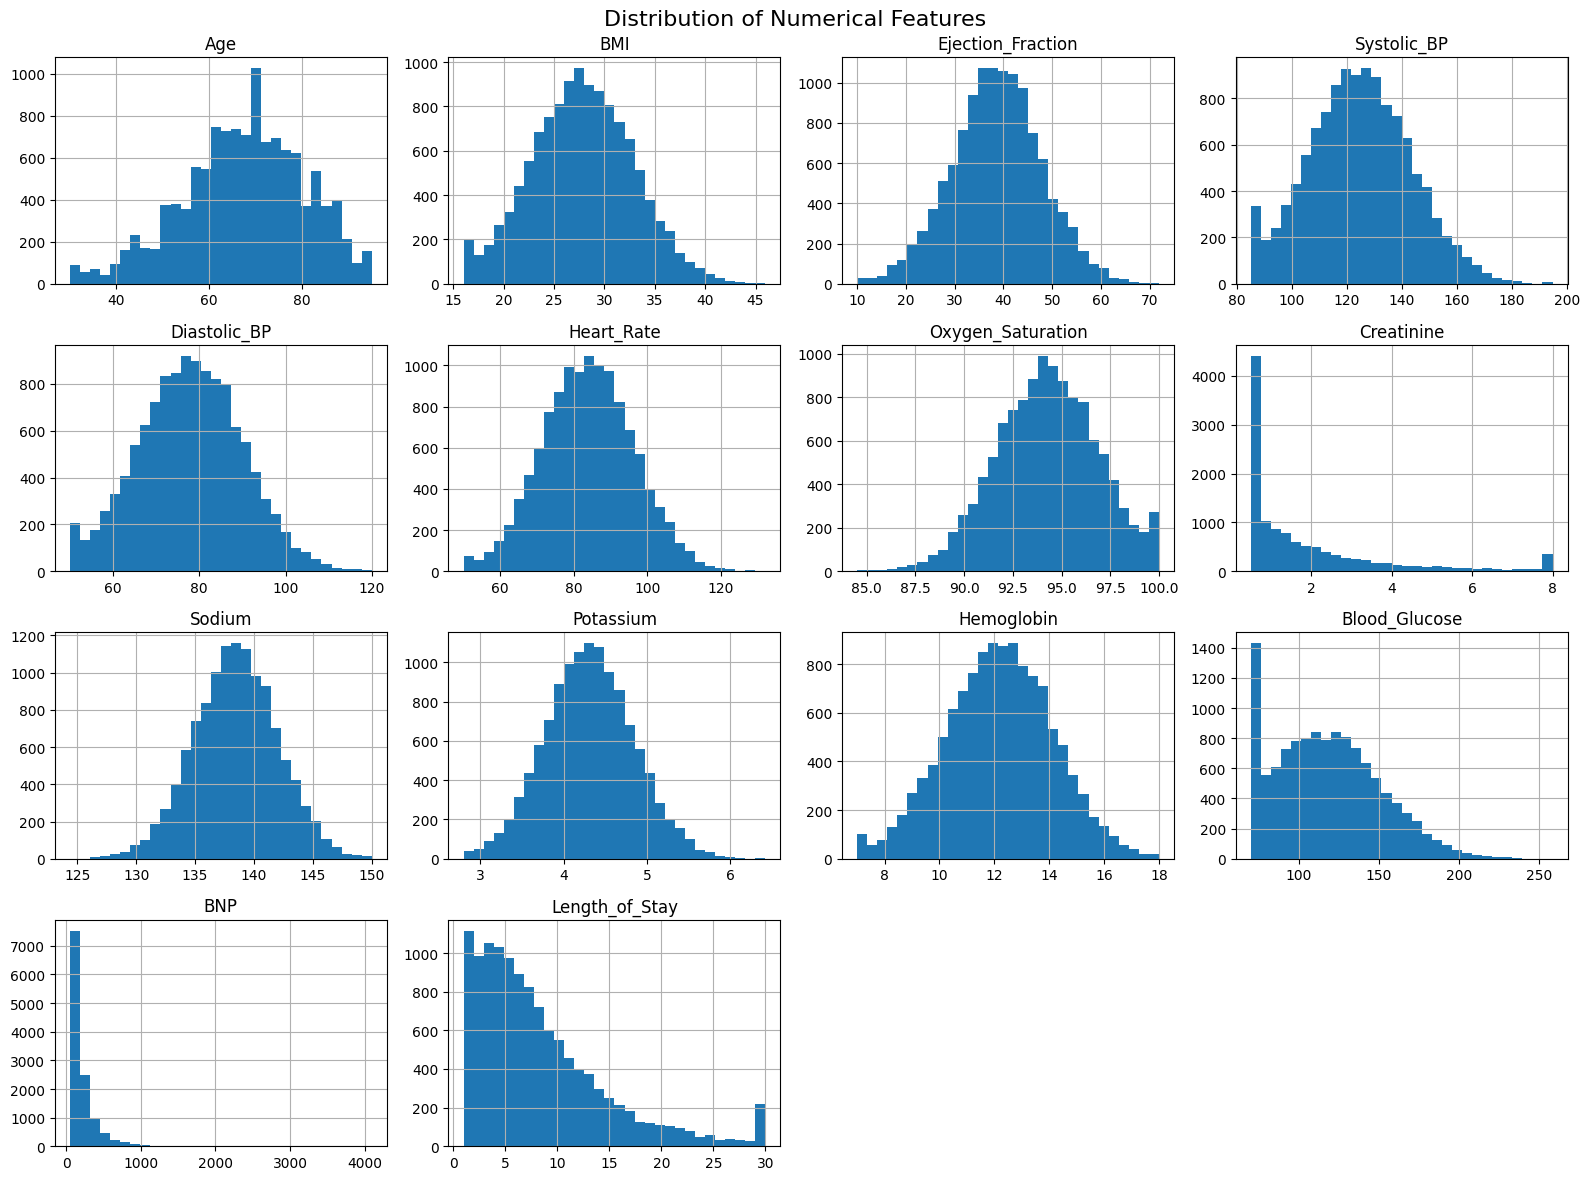

In [60]:
import matplotlib.pyplot as plt

numerical_columns = [
    "Age",
    "BMI",
    "Ejection_Fraction",
    "Systolic_BP",
    "Diastolic_BP",
    "Heart_Rate",
    "Oxygen_Saturation",
    "Creatinine",
    "Sodium",
    "Potassium",
    "Hemoglobin",
    "Blood_Glucose",
    "BNP",
    "Length_of_Stay"
]

df[numerical_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 3.4 Distribution of Categorical Features

Bar charts were created to visualize the distribution of the main categorical features, including gender, smoking status, alcohol consumption, and heart failure type. This helps provide a visual understanding of the categories present in the dataset.


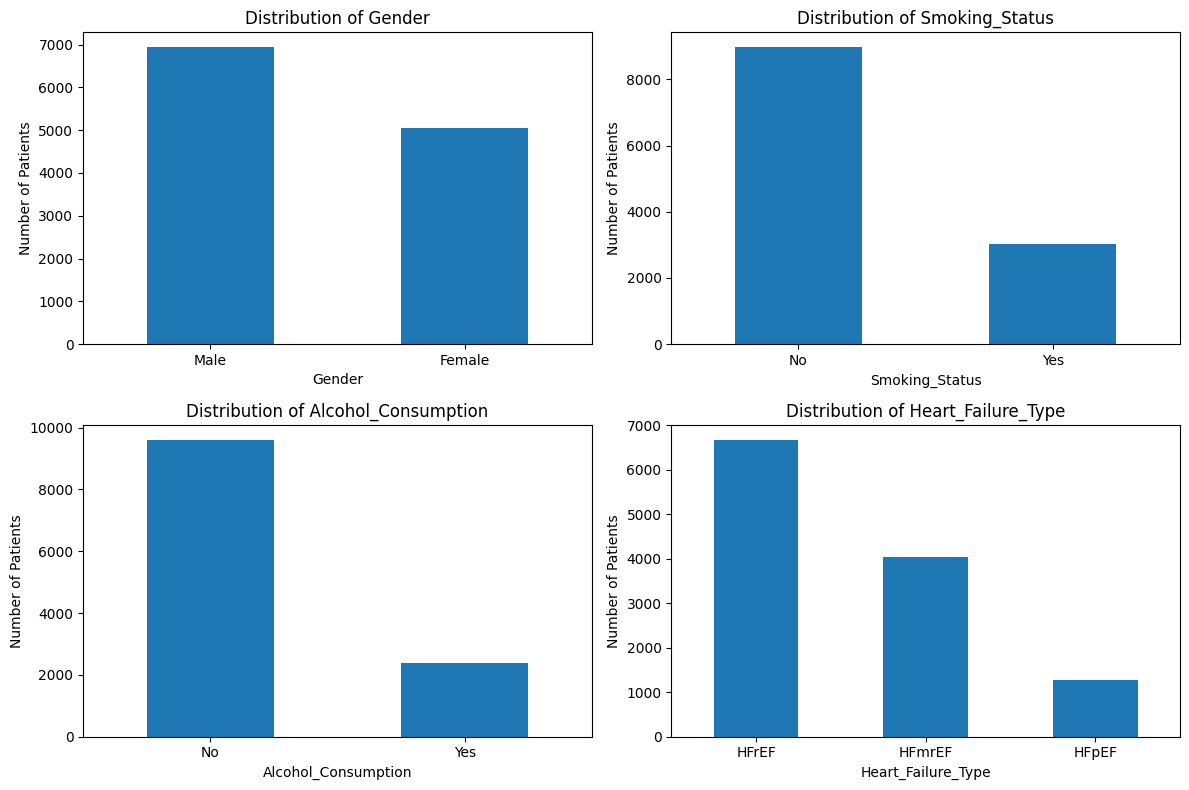

In [61]:
categorical_columns = [
    "Gender",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Heart_Failure_Type"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flat, categorical_columns):
    df[column].value_counts().plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Patients")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 3.5 Correlation Analysis

A correlation matrix was generated for the numerical features to examine the strength and direction of linear relationships between the variables. This analysis helps identify highly related features and provides an overall understanding of relationships within the numerical data.


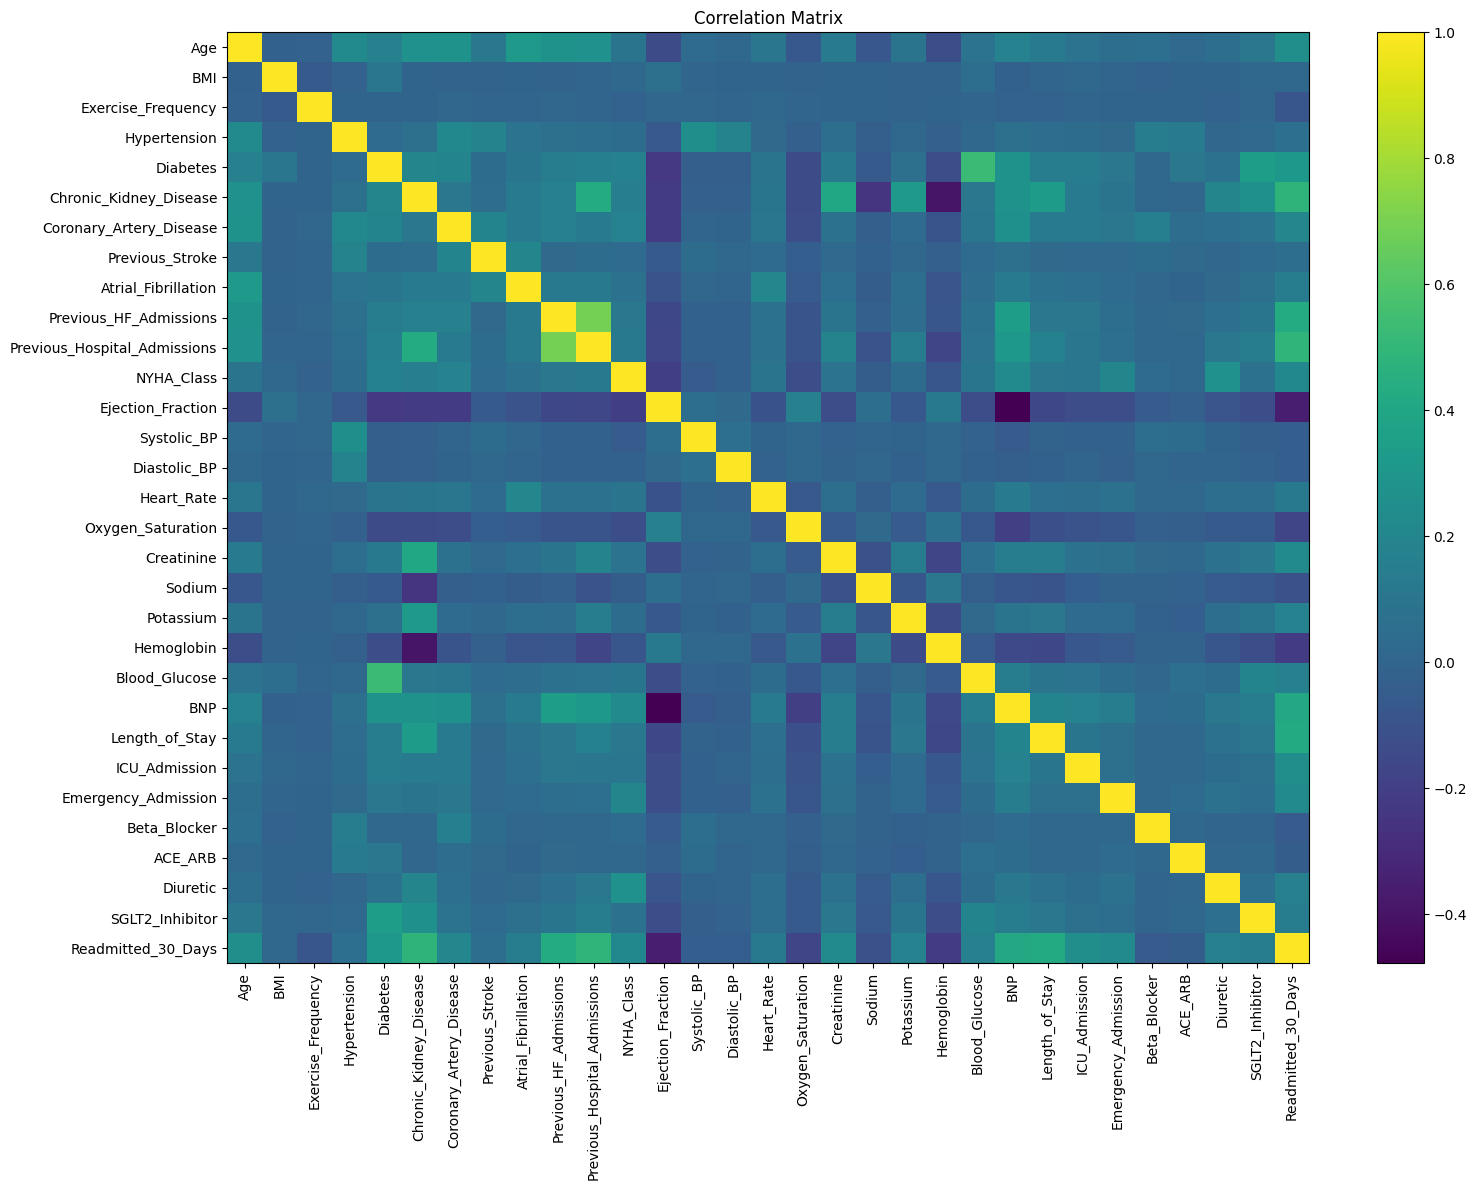

In [62]:
# Correlation matrix for numerical features

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(16, 12))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 3.6 Correlation of Features with Target

The correlation of each numerical feature with the target variable `Readmitted_30_Days` was examined. The correlations were sorted to identify features with relatively stronger positive or negative linear associations with 30-day readmission.


In [63]:
# Correlation of features with the target

target_correlation = (
    correlation_matrix["Readmitted_30_Days"]
    .sort_values(ascending=False)
)

print(target_correlation)

Readmitted_30_Days              1.000000
Previous_Hospital_Admissions    0.490127
Chronic_Kidney_Disease          0.481680
Previous_HF_Admissions          0.429939
Length_of_Stay                  0.423899
BNP                             0.413208
Diabetes                        0.313306
ICU_Admission                   0.255028
Age                             0.252523
Emergency_Admission             0.225189
Creatinine                      0.221584
NYHA_Class                      0.215274
Coronary_Artery_Disease         0.209077
Potassium                       0.174966
Blood_Glucose                   0.168968
Diuretic                        0.168934
Atrial_Fibrillation             0.148506
SGLT2_Inhibitor                 0.144705
Heart_Rate                      0.120096
Hypertension                    0.064018
Previous_Stroke                 0.054498
BMI                             0.015380
Diastolic_BP                   -0.034455
Systolic_BP                    -0.037719
ACE_ARB         

## 4. Data Quality Checks

## 4.1 Duplicate Row Check

The dataset was checked for duplicate rows to ensure that repeated records do not affect model training and evaluation.

In [64]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())
# Check whether any Patient_ID appears more than once

Duplicate rows: 0


## 4.2 Duplicate Patient ID Check

Patient IDs were checked for duplicates to ensure that each patient record has a unique identifier.

In [65]:
print("Duplicate Patient IDs:", df["Patient_ID"].duplicated().sum())

Duplicate Patient IDs: 0


## 4.3 Binary Feature Value Check

The unique values of the binary features were checked to ensure that they contain valid and consistent categories for model training.

In [66]:
# Check values in binary columns

binary_columns = [
    "Hypertension",
    "Diabetes",
    "Chronic_Kidney_Disease",
    "Coronary_Artery_Disease",
    "Previous_Stroke",
    "Atrial_Fibrillation",
    "ICU_Admission",
    "Emergency_Admission",
    "Beta_Blocker",
    "ACE_ARB",
    "Diuretic",
    "SGLT2_Inhibitor",
    "Readmitted_30_Days"
]

for column in binary_columns:
    print(f"{column}: {sorted(df[column].unique())}")

Hypertension: [np.int64(0), np.int64(1)]
Diabetes: [np.int64(0), np.int64(1)]
Chronic_Kidney_Disease: [np.int64(0), np.int64(1)]
Coronary_Artery_Disease: [np.int64(0), np.int64(1)]
Previous_Stroke: [np.int64(0), np.int64(1)]
Atrial_Fibrillation: [np.int64(0), np.int64(1)]
ICU_Admission: [np.int64(0), np.int64(1)]
Emergency_Admission: [np.int64(0), np.int64(1)]
Beta_Blocker: [np.int64(0), np.int64(1)]
ACE_ARB: [np.int64(0), np.int64(1)]
Diuretic: [np.int64(0), np.int64(1)]
SGLT2_Inhibitor: [np.int64(0), np.int64(1)]
Readmitted_30_Days: [np.int64(0), np.int64(1)]


## 4.4 Categorical Feature Value Check

The unique values of the categorical features were examined to verify that the dataset contains valid and expected categories.

In [67]:
categorical_columns = [
    "Gender",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Heart_Failure_Type"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Gender:
['Female' 'Male']

Smoking_Status:
['No' 'Yes']

Alcohol_Consumption:
['No' 'Yes']

Heart_Failure_Type:
['HFmrEF' 'HFrEF' 'HFpEF']


## 4.5 Numerical Range Validation

Reasonable value ranges were defined for important numerical features such as Age, BMI, blood pressure, heart rate, and laboratory measurements. The number of values falling outside these ranges was checked to identify potential data-quality issues.

In [68]:
range_checks = {
    "Age": (0, 120),
    "BMI": (10, 80),
    "Ejection_Fraction": (0, 100),
    "Systolic_BP": (50, 250),
    "Diastolic_BP": (30, 150),
    "Heart_Rate": (30, 250),
    "Oxygen_Saturation": (50, 100),
    "Creatinine": (0, 20),
    "Sodium": (100, 180),
    "Potassium": (1, 10),
    "Hemoglobin": (3, 25),
    "Blood_Glucose": (20, 600)
}

for column, (minimum, maximum) in range_checks.items():
    invalid = ((df[column] < minimum) | (df[column] > maximum)).sum()
    print(f"{column}: {invalid} values outside check range")

Age: 0 values outside check range
BMI: 0 values outside check range
Ejection_Fraction: 0 values outside check range
Systolic_BP: 0 values outside check range
Diastolic_BP: 0 values outside check range
Heart_Rate: 0 values outside check range
Oxygen_Saturation: 0 values outside check range
Creatinine: 0 values outside check range
Sodium: 0 values outside check range
Potassium: 0 values outside check range
Hemoglobin: 0 values outside check range
Blood_Glucose: 0 values outside check range


## 4.6 Data Leakage Analysis

Data leakage occurs when information that would not be available at the time of prediction is used by a machine-learning model. This can lead to unrealistically high model performance and poor generalization to new patients.

For this project, the target variable `Readmitted_30_Days` was separated from the input features before model training. `Patient_ID` was treated as an identifier rather than a predictive feature and was not used for model training.

The dataset was also reviewed for variables that could directly reveal the target or contain information that would only become available after the prediction point. The preprocessing and scaling steps were fitted using only the training data and then applied to the test data to prevent information from the test set influencing model training.

Based on these checks, no obvious target leakage was identified in the features used for model training.


## 5. Target Relationship Analysis

## 5.1 Readmission Rate by Heart Failure Type

The 30-day readmission rate was compared across different heart failure types. The count and mean of Readmitted_30_Days were calculated for each category.

In [69]:
print("Readmission Rate by Heart Failure Type:")
display(
    df.groupby("Heart_Failure_Type")["Readmitted_30_Days"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)


Readmission Rate by Heart Failure Type:


,count,mean
Heart_Failure_Type,,
HFrEF,6679,0.411738
HFmrEF,4044,0.183976
HFpEF,1277,0.083007


## 5.2 Readmission Rate by NYHA Class

The 30-day readmission rate was examined across different NYHA classes. The count and mean of Readmitted_30_Days were calculated for each class.

In [70]:
print("Readmission Rate by NYHA Class:")
display(
    df.groupby("NYHA_Class")["Readmitted_30_Days"]
      .agg(["count", "mean"])
)

Readmission Rate by NYHA Class:


,count,mean
NYHA_Class,,
1,3598,0.145914
2,2975,0.338487
3,3972,0.356999
4,1455,0.446735


## 5.3 Readmission Rate by Previous Heart Failure Admissions

The 30-day readmission rate was examined based on the number of previous heart-failure admissions. The count and mean of Readmitted_30_Days were calculated for each admission group.

In [71]:
df.groupby("Previous_HF_Admissions")["Readmitted_30_Days"].agg(
    ["count", "mean"]
)

,count,mean
Previous_HF_Admissions,,
0,6785,0.154753
1,3503,0.381958
2,1221,0.640459
3,368,0.853261
4,93,0.924731
5,29,1.000000
7,1,1.000000


## 5.4 Readmission Rate by ICU Admission

The 30-day readmission rate was examined based on whether patients were admitted to the ICU. The count and mean of `Readmitted_30_Days` were calculated for each ICU admission group to understand whether readmission rates vary between patients with and without ICU admission.


In [72]:
df.groupby("ICU_Admission")["Readmitted_30_Days"].agg(
    ["count", "mean"]
)

,count,mean
ICU_Admission,,
0,7921,0.216134
1,4079,0.462859


## 5.5 Numerical Feature Comparison by Readmission

The mean values of selected numerical features were compared between patients who were readmitted within 30 days and those who were not. This analysis helps identify differences in patient characteristics, clinical measurements, and hospitalization-related factors across the two target groups.


In [73]:
df.groupby("Readmitted_30_Days")[
    [
        "Age",
        "BMI",
        "Ejection_Fraction",
        "Systolic_BP",
        "Heart_Rate",
        "Creatinine",
        "Sodium",
        "Hemoglobin",
        "Blood_Glucose",
        "BNP",
        "Length_of_Stay"
    ]
].mean().T

Readmitted_30_Days,0,1
Age,65.234286,72.441389
BMI,27.740206,27.909195
Ejection_Fraction,40.778738,33.665732
Systolic_BP,125.170573,123.641466
Heart_Rate,82.849194,86.089879
Creatinine,1.613329,2.508248
Sodium,138.715328,137.856631
Hemoglobin,12.461187,11.515519
Blood_Glucose,114.461252,126.516712
BNP,149.825371,333.527914


## 5.6 Readmission Rate by Selected Features

The 30-day readmission rate was compared across selected demographic, behavioral, clinical, and admission-related features. The number of patients and readmission rate for each category were calculated to identify differences in readmission patterns across these groups.


In [74]:
# Readmission rate by selected features

features_to_analyze = [
    "Gender",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Heart_Failure_Type",
    "NYHA_Class",
    "ICU_Admission",
    "Emergency_Admission"
]

for feature in features_to_analyze:
    print(f"\n--- {feature} ---")
    result = df.groupby(feature)["Readmitted_30_Days"].agg(
        ["count", "mean"]
    )
    result["Readmission_Rate_%"] = result["mean"] * 100
    print(result.drop(columns="mean"))


--- Gender ---
        count  Readmission_Rate_%
Gender                           
Female   5059           29.788496
Male     6941           30.154156

--- Smoking_Status ---
                count  Readmission_Rate_%
Smoking_Status                           
No               8971           29.952068
Yes              3029           30.141961

--- Alcohol_Consumption ---
                     count  Readmission_Rate_%
Alcohol_Consumption                           
No                    9610           29.542144
Yes                   2390           31.841004

--- Heart_Failure_Type ---
                    count  Readmission_Rate_%
Heart_Failure_Type                           
HFmrEF               4044           18.397626
HFpEF                1277            8.300705
HFrEF                6679           41.173828

--- NYHA_Class ---
            count  Readmission_Rate_%
NYHA_Class                           
1            3598           14.591440
2            2975           33.848739
3        

## 5.7 Visualization of Readmission Rates

Bar charts were created to visualize the 30-day readmission rates across selected demographic, behavioral, and clinical features. The visualizations make it easier to compare readmission rates between different categories.


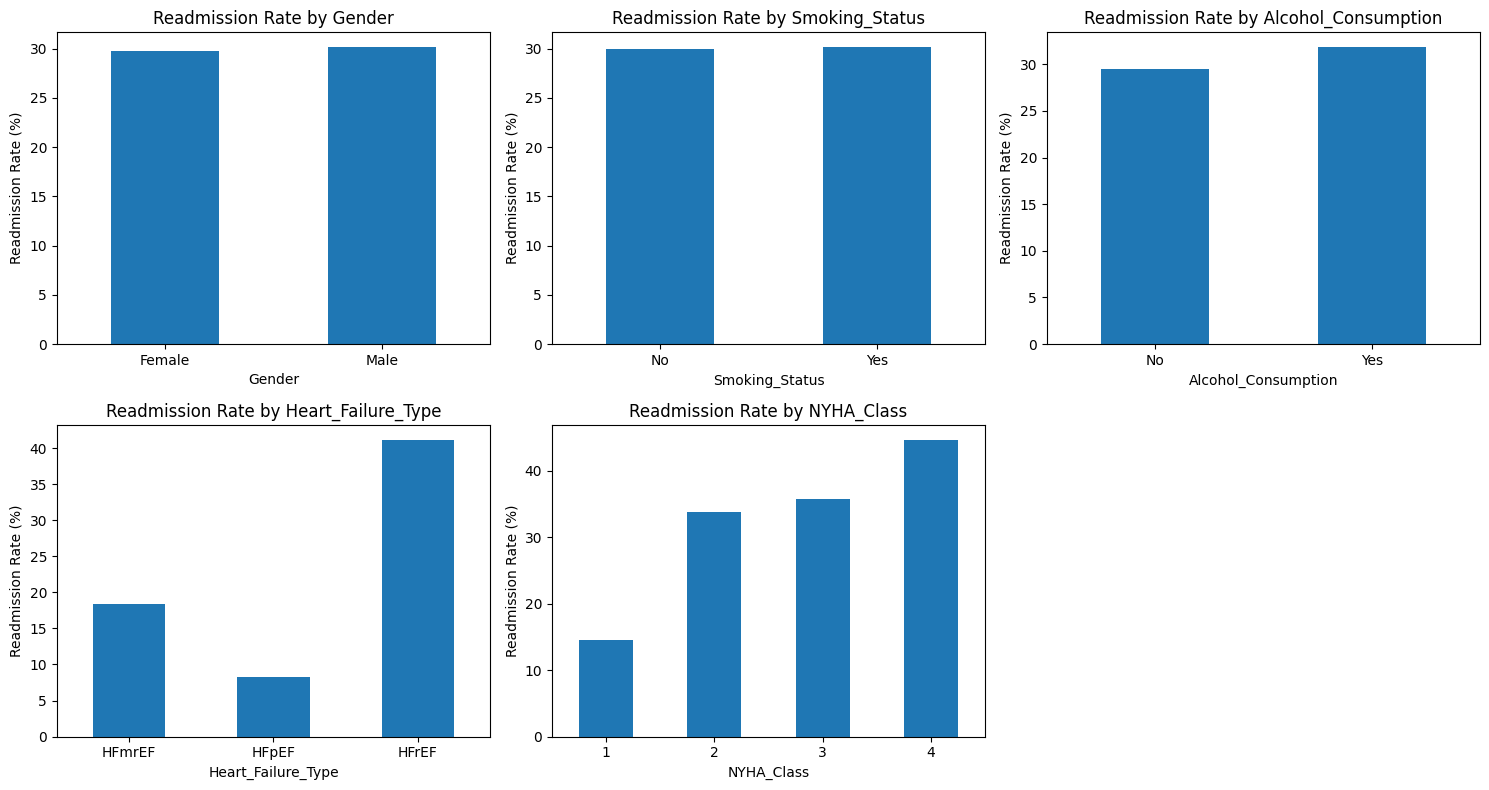

In [75]:
import matplotlib.pyplot as plt

features_to_plot = [
    "Gender",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Heart_Failure_Type",
    "NYHA_Class"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, features_to_plot):
    rate = df.groupby(feature)["Readmitted_30_Days"].mean() * 100
    rate.plot(kind="bar", ax=ax)
    
    ax.set_title(f"Readmission Rate by {feature}")
    ax.set_ylabel("Readmission Rate (%)")
    ax.set_xlabel(feature)
    ax.tick_params(axis="x", rotation=0)

# Hide unused subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# 6. Data Preprocessing

## 6.1 Separate Features and Target

The input features and target variable were separated before model training. `Patient_ID` was removed because it is an identifier and does not provide meaningful predictive information. The target variable `Readmitted_30_Days` was stored separately as `y`.


In [76]:
# Separate input features (X) and target variable (y)

X = df.drop(columns=["Patient_ID", "Readmitted_30_Days"])
y = df["Readmitted_30_Days"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12000, 34)
y shape: (12000,)


## 6.2 Identify Numerical and Categorical Features

The input features were divided into numerical and categorical columns based on their data types. This separation is required because numerical and categorical features require different preprocessing techniques before model training.


In [77]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'BMI', 'Exercise_Frequency', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke', 'Atrial_Fibrillation', 'Previous_HF_Admissions', 'Previous_Hospital_Admissions', 'NYHA_Class', 'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission', 'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic', 'SGLT2_Inhibitor']

Categorical features:
['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Heart_Failure_Type']


## 6.3 Train-Test Split

The dataset was divided into training and testing sets using an 80:20 split. Stratified sampling was applied to preserve the proportion of the target classes in both sets. A fixed random state was used to ensure reproducibility.


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (9600, 34)
Testing data: (2400, 34)

Training target distribution:
Readmitted_30_Days
0    0.7
1    0.3
Name: proportion, dtype: float64

Testing target distribution:
Readmitted_30_Days
0    0.7
1    0.3
Name: proportion, dtype: float64


## 6.4 Create Preprocessing Pipeline

A preprocessing pipeline was created to prepare the numerical and categorical features for machine learning. Numerical features were standardized using `StandardScaler`, while categorical features were converted into numerical form using one-hot encoding. The `handle_unknown="ignore"` option ensures that unseen categorical values in the test data do not cause errors during transformation.


In [79]:
# Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 6.5 Apply Preprocessing

The preprocessing pipeline was fitted using only the training data and then applied to both the training and testing datasets. Numerical features were standardized and categorical features were one-hot encoded. Fitting the preprocessing steps only on the training data helps prevent data leakage from the test set. The final shapes of the processed features and target variables were also verified.


In [80]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nFinal training data shape:", X_train_processed.shape)
print("Final testing data shape:", X_test_processed.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Processed training shape: (9600, 39)
Processed testing shape: (2400, 39)

Final training data shape: (9600, 39)
Final testing data shape: (2400, 39)
Training target shape: (9600,)
Testing target shape: (2400,)


# 7. Model Training and Evaluation

## 7.1 Logistic Regression Model

Logistic Regression was trained as a baseline binary classification model to predict whether a patient would be readmitted within 30 days. The model was trained using the preprocessed training data and evaluated on the unseen test data using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a confusion matrix.


In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
# Train Logistic Regression baseline model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [83]:
# Make predictions using Logistic Regression

y_pred_logistic = logistic_model.predict(X_test_processed)
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test_processed)
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.895
Precision: 0.8524
Recall   : 0.7861
F1-Score : 0.8179
ROC-AUC  : 0.9562


Confusion Matrix:
[[1582   98]
 [ 154  566]]


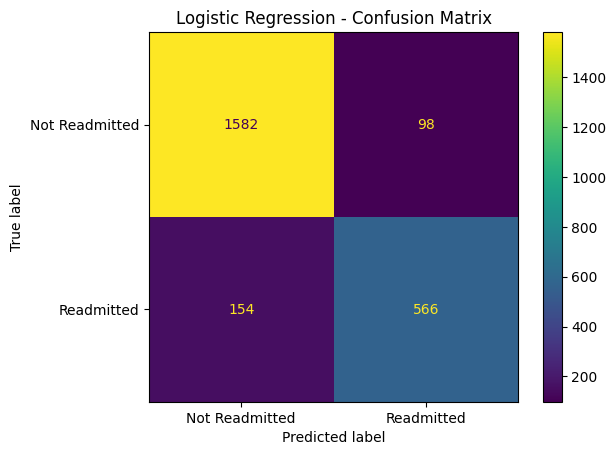

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 7.2 K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors (KNN) was trained as a second classification model for predicting 30-day hospital readmission. The baseline model was trained using the preprocessed training data and evaluated on the unseen test data.


In [86]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [87]:
y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

print("KNN predictions generated successfully.")

KNN predictions generated successfully.


In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
roc_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

KNN Results
-----------
Accuracy : 0.8417
Precision: 0.8232
Recall   : 0.6014
F1-Score : 0.695
ROC-AUC  : 0.8878


KNN Confusion Matrix:
[[1587   93]
 [ 287  433]]


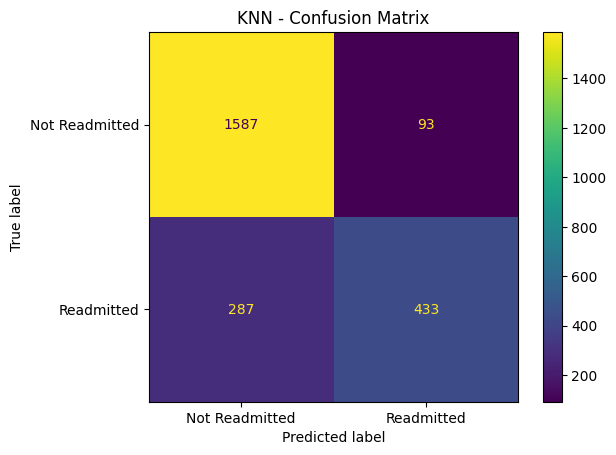

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

## 7.3 Decision Tree Model

In [90]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [91]:
y_pred_tree = decision_tree_model.predict(X_test_processed)
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Results
--------------------
Accuracy : 0.8383
Precision: 0.7578
Recall   : 0.6778
F1-Score : 0.7155
ROC-AUC  : 0.8907


Decision Tree Confusion Matrix:
[[1524  156]
 [ 232  488]]


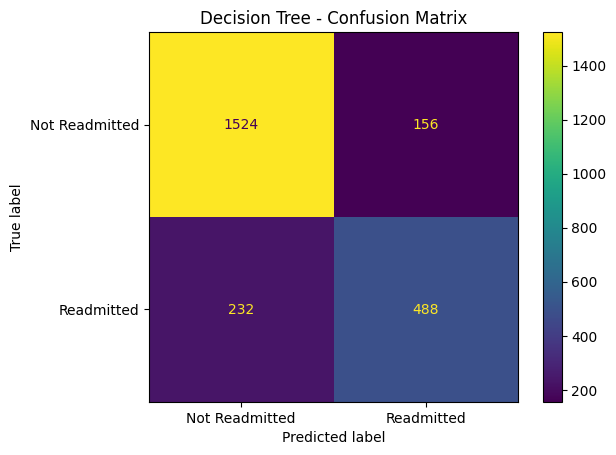

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

For this project:

- **True Negative (TN):** The patient was not readmitted within 30 days, and the model correctly predicted no readmission.
- **True Positive (TP):** The patient was readmitted within 30 days, and the model correctly predicted readmission.
- **False Positive (FP):** The patient was not readmitted within 30 days, but the model incorrectly predicted readmission.
- **False Negative (FN):** The patient was readmitted within 30 days, but the model incorrectly predicted no readmission.

In the context of heart-failure readmission, false negatives are particularly important because they represent patients who were actually readmitted but were not identified by the model.

## 7.4 ROC Curve Comparison

ROC curves were plotted for Logistic Regression, KNN, and Decision Tree to compare their ability to distinguish between patients who were and were not readmitted within 30 days. ROC-AUC was used as a threshold-independent performance measure, where a higher value indicates better separation between the two classes.


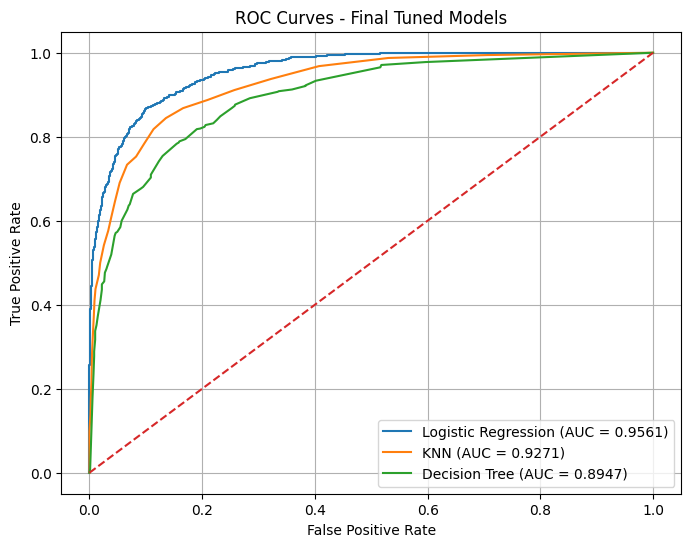

In [94]:
# ROC Curve Comparison - Final Tuned Models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# --------------------------------------------------
# Recreate final tuned models
# --------------------------------------------------

final_model = LogisticRegression(
    C=0.1,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

knn_final = KNeighborsClassifier(
    n_neighbors=31
)

dt_final = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)


# --------------------------------------------------
# Train final models
# --------------------------------------------------

final_model.fit(X_train_processed, y_train)
knn_final.fit(X_train_processed, y_train)
dt_final.fit(X_train_processed, y_train)


# --------------------------------------------------
# Final model probabilities
# --------------------------------------------------

y_prob_lr = final_model.predict_proba(X_test_processed)[:, 1]
y_prob_knn = knn_final.predict_proba(X_test_processed)[:, 1]
y_prob_dt = dt_final.predict_proba(X_test_processed)[:, 1]


# --------------------------------------------------
# Calculate ROC curves
# --------------------------------------------------

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)


# --------------------------------------------------
# Calculate AUC
# --------------------------------------------------

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_dt = roc_auc_score(y_test, y_prob_dt)


# --------------------------------------------------
# Plot ROC curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {auc_knn:.4f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Final Tuned Models")
plt.legend()
plt.grid(True)
plt.show()

## 7.5 Model Performance Comparison

The baseline performance of Logistic Regression, KNN, and Decision Tree was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC on the test dataset. These metrics provide a comprehensive view of the classification performance of the three models.


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Logistic Regression
y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

# KNN
y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

# Decision Tree
y_pred_dt = decision_tree_model.predict(X_test_processed)
y_prob_dt = decision_tree_model.predict_proba(X_test_processed)[:, 1]

# Create comparison table
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt)
    ]
})

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8950,0.8524,0.7861,0.8179,0.9562
1,KNN,0.8417,0.8232,0.6014,0.6950,0.8878
2,Decision Tree,0.8383,0.7578,0.6778,0.7155,0.8907


# 8. Model Validation and Improvement

## 8.1 Train vs Test Performance

Train and test ROC-AUC scores were compared for Logistic Regression, KNN, and Decision Tree. The difference between training and testing performance was examined to identify possible overfitting or underfitting and to assess how well each model generalizes to unseen data.


In [96]:
# Train vs Test ROC-AUC Performance for Final Models

from sklearn.metrics import roc_auc_score
import pandas as pd

# Logistic Regression - Final Model
train_prob_lr_final = final_model.predict_proba(X_train_processed)[:, 1]
test_prob_lr_final = final_model.predict_proba(X_test_processed)[:, 1]

# KNN - Final Model
train_prob_knn_final = knn_final.predict_proba(X_train_processed)[:, 1]
test_prob_knn_final = knn_final.predict_proba(X_test_processed)[:, 1]

# Decision Tree - Final Model
train_prob_dt_final = dt_final.predict_proba(X_train_processed)[:, 1]
test_prob_dt_final = dt_final.predict_proba(X_test_processed)[:, 1]

# Calculate ROC-AUC
train_auc_lr_final = roc_auc_score(y_train, train_prob_lr_final)
test_auc_lr_final = roc_auc_score(y_test, test_prob_lr_final)

train_auc_knn_final = roc_auc_score(y_train, train_prob_knn_final)
test_auc_knn_final = roc_auc_score(y_test, test_prob_knn_final)

train_auc_dt_final = roc_auc_score(y_train, train_prob_dt_final)
test_auc_dt_final = roc_auc_score(y_test, test_prob_dt_final)

# Create comparison table
train_test_results_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Train ROC-AUC": [
        train_auc_lr_final,
        train_auc_knn_final,
        train_auc_dt_final
    ],
    "Test ROC-AUC": [
        test_auc_lr_final,
        test_auc_knn_final,
        test_auc_dt_final
    ]
})

train_test_results_final["Train-Test Gap"] = (
    train_test_results_final["Train ROC-AUC"]
    - train_test_results_final["Test ROC-AUC"]
)

display(train_test_results_final.round(4))

,Model,Train ROC-AUC,Test ROC-AUC,Train-Test Gap
0,Logistic Regression,0.9537,0.9561,-0.0025
1,KNN,0.9398,0.9271,0.0127
2,Decision Tree,0.9170,0.8947,0.0223


## 8.2 Overfitting and Underfitting Diagnosis

Overfitting and underfitting were assessed by comparing the training and testing ROC-AUC scores of the final tuned models.

Logistic Regression showed very similar training and testing ROC-AUC values (0.9537 vs. 0.9561), with a train-test gap of -0.0025, indicating good generalization.

KNN showed a small train-test gap of 0.0127 (0.9398 training ROC-AUC vs. 0.9271 testing ROC-AUC). This does not provide strong evidence of overfitting.

Decision Tree showed a train-test gap of 0.0223 (0.9170 training ROC-AUC vs. 0.8947 testing ROC-AUC). Although the gap is larger than the other models, it is not large enough by itself to indicate severe overfitting.

Overall, the final models did not show strong evidence of overfitting. The training and testing performance was reasonably close, suggesting acceptable generalization on the held-out test set.


## 8.3 Logistic Regression Hyperparameter Tuning

Different values of `C` and solver options were evaluated for the Logistic Regression model using GridSearchCV with 5-fold cross-validation. The experiment helps identify suitable hyperparameters and improve the model's ROC-AUC performance.


In [97]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Define hyperparameters
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

# GridSearchCV
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train and tune
logistic_grid.fit(X_train, y_train)

print("Best Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(logistic_grid.best_score_, 4))

Best Parameters:
{'model__C': 0.1, 'model__solver': 'liblinear'}

Best Cross-Validation ROC-AUC:
0.9517


###  Interpretation

The GridSearchCV experiment identified `C = 0.1` and the `liblinear` solver as the best hyperparameter combination. The model achieved a mean cross-validation ROC-AUC of **0.9517** across 5 folds.

In [98]:
# Train the final Logistic Regression model
final_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train_processed, y_train)

print("Final Logistic Regression model trained successfully!")

Final Logistic Regression model trained successfully!


In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_final = final_model.predict(X_test_processed)
y_prob_final = final_model.predict_proba(X_test_processed)[:, 1]

print("Final Logistic Regression Results")
print("----------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_final), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_final), 4))

Final Logistic Regression Results
----------------------------------
Accuracy : 0.8942
Precision: 0.852
Recall   : 0.7833
F1-Score : 0.8162
ROC-AUC  : 0.9561


###  Interpretation

The Logistic Regression hyperparameter tuning experiment identified **C = 0.1** and the **liblinear** solver as the best hyperparameter combination. The model achieved a mean 5-fold cross-validation ROC-AUC of **0.9517**.

After training the final Logistic Regression model using these parameters, the model achieved a test ROC-AUC of **0.9561**, with an accuracy of **0.8942**, precision of **0.8520**, recall of **0.7833**, and F1-score of **0.8162**.


## 8.4 KNN Hyperparameter Experiment

Different values of K were evaluated for the K-Nearest Neighbors classifier using 5-fold cross-validation. The experiment examines how the choice of K affects ROC-AUC performance and helps identify a suitable neighborhood size.


In [100]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Different K values
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]

knn_cv_results = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn_model,
        X_train_processed,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    knn_cv_results.append({
        "K": k,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

knn_cv_results = pd.DataFrame(knn_cv_results)

display(knn_cv_results.round(4))

,K,Mean ROC-AUC,Std ROC-AUC
0,3,0.8557,0.0049
1,5,0.8815,0.0037
2,7,0.8964,0.0037
3,9,0.9051,0.0056
4,11,0.9086,0.0061
5,13,0.9132,0.0050
6,15,0.9146,0.0049
7,17,0.9160,0.0053
8,19,0.9177,0.0057
9,21,0.9196,0.0060


In [101]:
best_k = 31

knn_final = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_final.fit(X_train_processed, y_train)

y_pred_knn = knn_final.predict(X_test_processed)
y_prob_knn = knn_final.predict_proba(X_test_processed)[:, 1]

print("KNN Model")
print("Best K:", best_k)
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn), 4))
print("Precision:", round(precision_score(y_test, y_pred_knn), 4))
print("Recall:", round(recall_score(y_test, y_pred_knn), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_knn), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_knn), 4))

KNN Model
Best K: 31
Accuracy: 0.8496
Precision: 0.8811
Recall: 0.5764
F1-Score: 0.6969
ROC-AUC: 0.9271


## Interpretation

The cross-validation results showed that the mean ROC-AUC increased as K increased from 3 to 31. The highest mean ROC-AUC among the tested values was **0.9239 at K = 31**. Therefore, **K = 31** was selected for the final KNN model.

Using K = 31, the model achieved a test ROC-AUC of **0.9271**, with an accuracy of **0.8496**, precision of **0.8811**, recall of **0.5764**, and F1-Score of **0.6969**.


## 8.5 Decision Tree Hyperparameter Experiment

Different maximum tree depths were evaluated for the Decision Tree classifier using 5-fold cross-validation. The experiment examines how tree depth affects ROC-AUC performance and helps identify a suitable level of model complexity.


In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Different maximum depths
depth_values = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

dt_cv_results = []

for depth in depth_values:
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        dt_model,
        X_train_processed,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    dt_cv_results.append({
        "Max Depth": depth,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

dt_cv_results = pd.DataFrame(dt_cv_results)

display(dt_cv_results.round(4))

,Max Depth,Mean ROC-AUC,Std ROC-AUC
0,2,0.8037,0.0089
1,3,0.8454,0.0098
2,4,0.8686,0.0059
3,5,0.8785,0.0059
4,6,0.8810,0.0077
5,7,0.8696,0.0088
6,8,0.8408,0.0145
7,10,0.7818,0.0091
8,12,0.7460,0.0125
9,15,0.7345,0.0165


In [103]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train final Decision Tree using the best depth
best_depth = 6

dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_final.fit(X_train_processed, y_train)

# Predictions
y_pred_dt_final = dt_final.predict(X_test_processed)
y_prob_dt_final = dt_final.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Final Decision Tree Model")
print("-------------------------")
print("Best Max Depth:", best_depth)
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt_final), 4))
print("Recall:", round(recall_score(y_test, y_pred_dt_final), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_dt_final), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt_final), 4))

Final Decision Tree Model
-------------------------
Best Max Depth: 6
Accuracy: 0.845
Precision: 0.7862
Recall: 0.6639
F1-Score: 0.7199
ROC-AUC: 0.8947


###  Interpretation

The cross-validation results show that the Decision Tree achieved its highest mean ROC-AUC of **0.8810** at a maximum depth of **6**. Performance decreased when the tree depth was increased beyond 6. Therefore, **max_depth = 6** was selected for the final Decision Tree model.


## 8.6 Cross-Validation

Cross-validation was performed using 5 folds to evaluate the consistency and generalization of the Logistic Regression model. The training data was divided into five subsets, with each subset used once as validation data while the remaining subsets were used for training. ROC-AUC was used as the evaluation metric, and the mean and standard deviation of the scores were calculated.


In [104]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("5-Fold Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

5-Fold Cross-Validation ROC-AUC Scores:
[0.9514496  0.95618128 0.95006485 0.94504511 0.95576663]

Mean ROC-AUC: 0.9517
Standard Deviation: 0.0041


### Interpretation

The Logistic Regression model achieved a mean 5-fold cross-validation ROC-AUC of **0.9517** with a standard deviation of **0.0041**. The small standard deviation indicates that the model produced consistent ROC-AUC performance across the five validation folds.


## 9. Final Model Comparison


In [105]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# --------------------------------------------------
# Recreate final models
# --------------------------------------------------

# Final Logistic Regression
final_model = LogisticRegression(
    C=0.1,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train_processed, y_train)


# Final KNN
knn_final = KNeighborsClassifier(n_neighbors=31)

knn_final.fit(X_train_processed, y_train)


# Final Decision Tree
dt_final = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_final.fit(X_train_processed, y_train)


# --------------------------------------------------
# Generate final predictions
# --------------------------------------------------

y_pred_lr = final_model.predict(X_test_processed)
y_prob_lr = final_model.predict_proba(X_test_processed)[:, 1]

y_pred_knn = knn_final.predict(X_test_processed)
y_prob_knn = knn_final.predict_proba(X_test_processed)[:, 1]

y_pred_dt = dt_final.predict(X_test_processed)
y_prob_dt = dt_final.predict_proba(X_test_processed)[:, 1]


# --------------------------------------------------
# Create final comparison table
# --------------------------------------------------

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt)
    ]
})


# Display final results
display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8942,0.8520,0.7833,0.8162,0.9561
1,KNN,0.8496,0.8811,0.5764,0.6969,0.9271
2,Decision Tree,0.8450,0.7862,0.6639,0.7199,0.8947


In [106]:
# Final Model Comparison with Train Accuracy and Fit Diagnosis

from sklearn.metrics import accuracy_score, roc_auc_score

# --------------------------------------------------
# Training predictions for final models
# --------------------------------------------------

train_pred_lr = final_model.predict(X_train_processed)
train_pred_knn = knn_final.predict(X_train_processed)
train_pred_dt = dt_final.predict(X_train_processed)

# Training accuracy
train_acc_lr = accuracy_score(y_train, train_pred_lr)
train_acc_knn = accuracy_score(y_train, train_pred_knn)
train_acc_dt = accuracy_score(y_train, train_pred_dt)


# --------------------------------------------------
# Calculate Train and Test ROC-AUC
# --------------------------------------------------

train_auc_lr = roc_auc_score(
    y_train,
    final_model.predict_proba(X_train_processed)[:, 1]
)

test_auc_lr = roc_auc_score(
    y_test,
    final_model.predict_proba(X_test_processed)[:, 1]
)

train_auc_knn = roc_auc_score(
    y_train,
    knn_final.predict_proba(X_train_processed)[:, 1]
)

test_auc_knn = roc_auc_score(
    y_test,
    knn_final.predict_proba(X_test_processed)[:, 1]
)

train_auc_dt = roc_auc_score(
    y_train,
    dt_final.predict_proba(X_train_processed)[:, 1]
)

test_auc_dt = roc_auc_score(
    y_test,
    dt_final.predict_proba(X_test_processed)[:, 1]
)


# --------------------------------------------------
# Calculate Train-Test ROC-AUC gaps
# --------------------------------------------------

roc_auc_gaps = [
    abs(train_auc_lr - test_auc_lr),
    abs(train_auc_knn - test_auc_knn),
    abs(train_auc_dt - test_auc_dt)
]


# --------------------------------------------------
# Add fit diagnosis
# --------------------------------------------------

fit_diagnosis = []

for gap in roc_auc_gaps:
    if gap > 0.05:
        fit_diagnosis.append("Possible Overfitting")
    else:
        fit_diagnosis.append("No major overfitting/underfitting")


# --------------------------------------------------
# Create final comparison table
# --------------------------------------------------

final_comparison = final_results.copy()

final_comparison["Train Acc."] = [
    train_acc_lr,
    train_acc_knn,
    train_acc_dt
]

# Rename test accuracy column
final_comparison.rename(
    columns={"Accuracy": "Test Acc."},
    inplace=True
)

final_comparison["Fit diagnosis"] = fit_diagnosis


# --------------------------------------------------
# Reorder columns
# --------------------------------------------------

final_comparison = final_comparison[
    [
        "Model",
        "Train Acc.",
        "Test Acc.",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Fit diagnosis"
    ]
]


# Display final comparison
display(final_comparison.round(4))

,Model,Train Acc.,Test Acc.,Precision,Recall,F1-Score,ROC-AUC,Fit diagnosis
0,Logistic Regression,0.8947,0.8942,0.8520,0.7833,0.8162,0.9561,No major overfitting/underfitting
1,KNN,0.8547,0.8496,0.8811,0.5764,0.6969,0.9271,No major overfitting/underfitting
2,Decision Tree,0.8635,0.8450,0.7862,0.6639,0.7199,0.8947,No major overfitting/underfitting


### Interpretation

The final test-set results show that the three models achieved different levels of performance across the evaluation metrics. Logistic Regression achieved a test ROC-AUC of **0.9561**, KNN achieved **0.9271**, and Decision Tree achieved **0.8947**.

The results also show differences between precision and recall. KNN achieved the highest precision among the three models, while Logistic Regression achieved higher recall and F1-score than KNN. These differences indicate that the models make different trade-offs when identifying patients at risk of 30-day readmission.

Overall, the comparison provides a clear view of the strengths and limitations of each model across multiple evaluation metrics.


## 10. Additional Required Analysis

This section provides additional analysis required for the final model comparison. The models are compared using multiple evaluation metrics, and their training and test performance are examined to assess generalization and identify possible overfitting or underfitting.


### 10.1 Metric Comparison Chart

The final Logistic Regression, KNN, and Decision Tree models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. This visualization provides a direct comparison of the main test-set performance metrics across the three models.


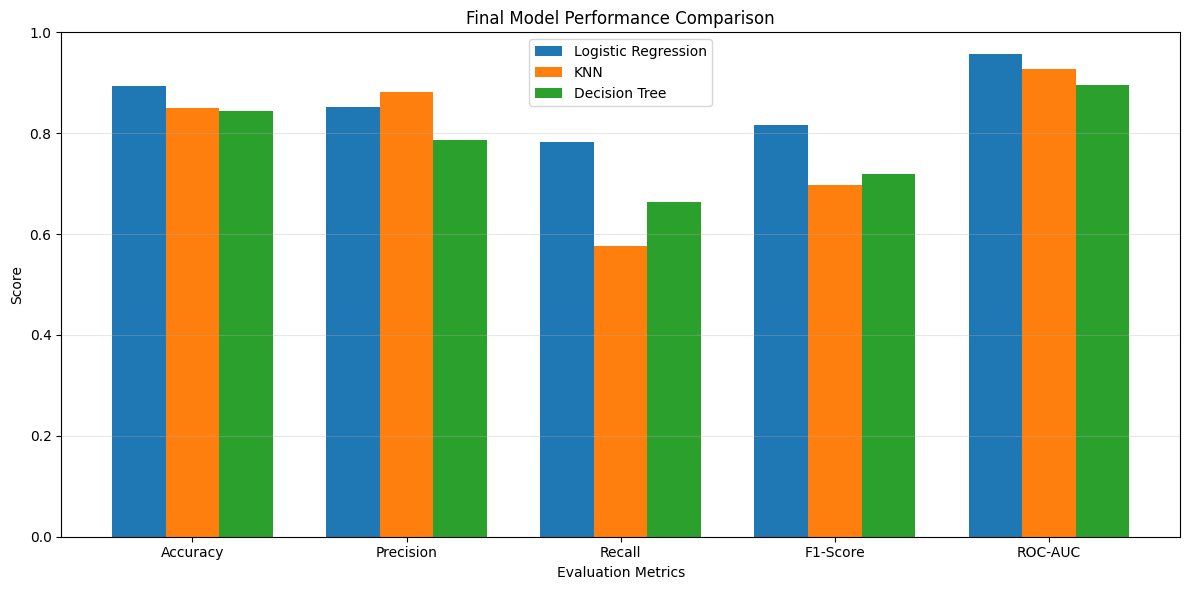

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Final model scores
logistic_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_prob_lr)
]

knn_scores = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    roc_auc_score(y_test, y_prob_knn)
]

dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_prob_dt)
]

# X-axis positions
x = np.arange(len(metrics))
width = 0.25

# Create chart
plt.figure(figsize=(12, 6))

plt.bar(x - width, logistic_scores, width, label="Logistic Regression")
plt.bar(x, knn_scores, width, label="KNN")
plt.bar(x + width, dt_scores, width, label="Decision Tree")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Final Model Performance Comparison")

plt.xticks(x, metrics)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10.2 Train vs Test Performance


In [108]:
# Display Train vs Test Performance - Final Models

import pandas as pd
from sklearn.metrics import roc_auc_score

# Calculate Train ROC-AUC
train_auc_lr = roc_auc_score(
    y_train,
    final_model.predict_proba(X_train_processed)[:, 1]
)

train_auc_knn = roc_auc_score(
    y_train,
    knn_final.predict_proba(X_train_processed)[:, 1]
)

train_auc_dt = roc_auc_score(
    y_train,
    dt_final.predict_proba(X_train_processed)[:, 1]
)

# Calculate Test ROC-AUC
test_auc_lr = roc_auc_score(
    y_test,
    final_model.predict_proba(X_test_processed)[:, 1]
)

test_auc_knn = roc_auc_score(
    y_test,
    knn_final.predict_proba(X_test_processed)[:, 1]
)

test_auc_dt = roc_auc_score(
    y_test,
    dt_final.predict_proba(X_test_processed)[:, 1]
)

# Create final Train vs Test table
train_test_results_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Train ROC-AUC": [
        train_auc_lr,
        train_auc_knn,
        train_auc_dt
    ],
    "Test ROC-AUC": [
        test_auc_lr,
        test_auc_knn,
        test_auc_dt
    ]
})

# Calculate Train-Test Gap
train_test_results_final["Train-Test Gap"] = (
    train_test_results_final["Train ROC-AUC"]
    - train_test_results_final["Test ROC-AUC"]
).abs()

# Display
display(train_test_results_final.round(4))

,Model,Train ROC-AUC,Test ROC-AUC,Train-Test Gap
0,Logistic Regression,0.9537,0.9561,0.0025
1,KNN,0.9398,0.9271,0.0127
2,Decision Tree,0.9170,0.8947,0.0223


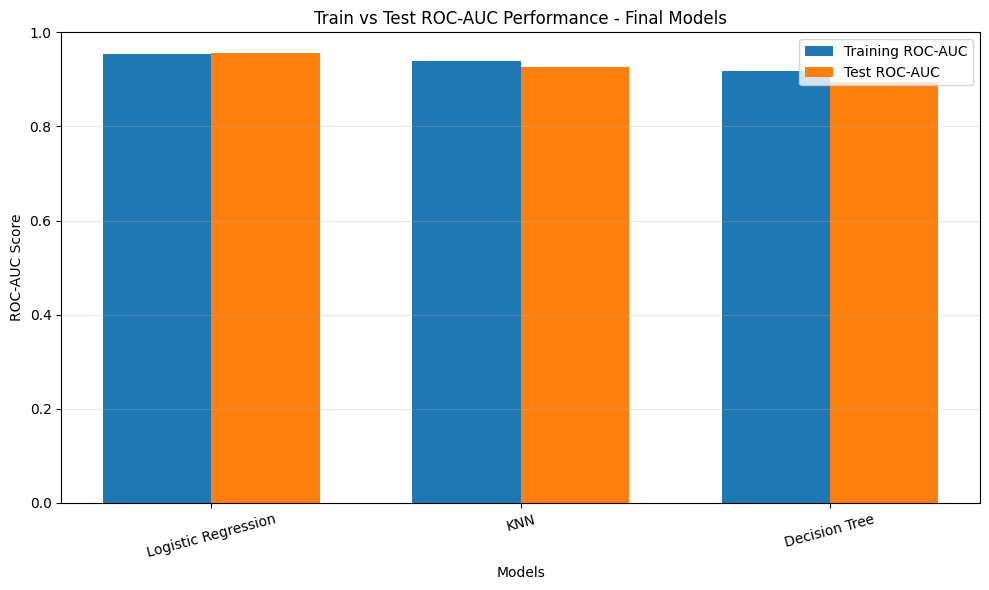

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model names
models = train_test_results_final["Model"]

# Extract train and test ROC-AUC scores
train_scores = train_test_results_final["Train ROC-AUC"]
test_scores = train_test_results_final["Test ROC-AUC"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    train_scores,
    width,
    label="Training ROC-AUC"
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label="Test ROC-AUC"
)

plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Train vs Test ROC-AUC Performance - Final Models")
plt.xticks(x, models, rotation=15)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

###  Interpretaion

The train and test ROC-AUC scores are compared to evaluate the generalization performance of the three classification models. Training ROC-AUC represents the model's performance on the training data, while test ROC-AUC represents performance on unseen test data.

Logistic Regression shows similar training and test ROC-AUC values, indicating consistent performance between the training and test datasets. KNN shows a larger difference between its training and test ROC-AUC values, indicating a greater change in performance on unseen data. Decision Tree shows a relatively small difference between its training and test ROC-AUC values.

These differences will be examined further in the overfitting and underfitting diagnosis in Section 10.3.


### 10.3 Overfitting and Underfitting Diagnosis

In [110]:
# Overfitting and Underfitting Diagnosis

print("Overfitting and Underfitting Diagnosis")
print("-" * 50)

for model, train, test in zip(models, train_scores, test_scores):
    difference = train - test

    print(f"{model}:")
    print(f"  Training ROC-AUC: {train:.4f}")
    print(f"  Test ROC-AUC    : {test:.4f}")
    print(f"  Difference      : {difference:.4f}")

    if difference > 0.05:
        print("  Diagnosis: Possible overfitting")
    elif difference < -0.05:
        print("  Diagnosis: Possible underfitting")
    else:
        print("  Diagnosis: No major overfitting/underfitting detected")

    print()

Overfitting and Underfitting Diagnosis
--------------------------------------------------
Logistic Regression:
  Training ROC-AUC: 0.9537
  Test ROC-AUC    : 0.9561
  Difference      : -0.0025
  Diagnosis: No major overfitting/underfitting detected

KNN:
  Training ROC-AUC: 0.9398
  Test ROC-AUC    : 0.9271
  Difference      : 0.0127
  Diagnosis: No major overfitting/underfitting detected

Decision Tree:
  Training ROC-AUC: 0.9170
  Test ROC-AUC    : 0.8947
  Difference      : 0.0223
  Diagnosis: No major overfitting/underfitting detected



#### Interpretation

The difference between training and test ROC-AUC is examined to identify potential overfitting or underfitting.

Logistic Regression has very similar training and test ROC-AUC values, with no major performance gap. This indicates consistent generalization between the training and test datasets.

KNN shows a noticeable decrease in ROC-AUC from the training data to the test data. This larger gap indicates possible overfitting, where the model performs better on the training data than on unseen data.

Decision Tree shows a relatively small difference between training and test ROC-AUC values. Therefore, no major overfitting or underfitting is indicated based on this comparison.

Overall, the train-test comparison provides evidence about model generalization and is considered along with cross-validation and other evaluation metrics.

# 11. Core Questions

### Q1. What is the class distribution of the target? Is the dataset balanced or imbalanced, and why does that matter?

The target variable `Readmitted_30_Days` contains 8,400 class 0 observations (70%) and 3,600 class 1 observations (30%). Therefore, the dataset is **imbalanced**, because the two classes are not represented equally.

This matters because a model can achieve relatively high accuracy by predicting the majority class more frequently while performing poorly on the minority class. Therefore, Accuracy alone is not sufficient for evaluating this problem. Precision, Recall, F1-score, and ROC-AUC should also be considered.

### Q2. What preprocessing steps did you perform? For each step, explain why it was necessary and whether it was fitted using training data only.

The preprocessing included separating the target variable from the input features, identifying numerical and categorical features, encoding categorical variables, and scaling numerical features where required.

Categorical variables were converted into numerical representations using encoding so that machine-learning algorithms could process them. Numerical features were scaled because KNN is sensitive to differences in feature magnitude.

The preprocessing components were fitted using the **training data only** and then applied to the test data. This prevents information from the test set from influencing the training process and helps avoid data leakage.

### Q3. Why does Logistic Regression generally require scaled numeric features less critically than KNN, while KNN is strongly affected by feature scale?

Logistic Regression can generally work without feature scaling because its coefficients can adjust to differences in feature magnitude. However, scaling can still be useful for numerical stability, regularization, and making coefficients more comparable.

KNN is strongly affected by feature scale because it uses distance calculations to determine which observations are nearest. A feature with a much larger numerical range can dominate the distance calculation. Scaling puts numerical features on a more comparable scale so that no single feature dominates simply because of its magnitude.

### Q4. What value of k did you use for KNN? Show how you selected it. Discuss what happens when k is too small versus too large.

The selected value of **k was 31**.

The value of k was selected by evaluating different candidate values using cross-validation and comparing their ROC-AUC performance. The results showed that the ROC-AUC increased as k increased through the tested range, with k = 31 selected as the final value based on the model-selection process.

If k is too small, KNN becomes highly sensitive to individual training observations and noise, which can increase the risk of overfitting. If k is too large, the model considers too many neighbours and can become overly generalized, potentially missing important local patterns and leading to underfitting.

### Q5. What settings did you use for the Decision Tree? Explain how tree depth and minimum-sample constraints can affect generalization.

The final Decision Tree was configured with a **maximum depth of 6** and `random_state=42`.

Limiting the maximum depth prevents the tree from becoming unnecessarily complex. A very deep tree can learn detailed patterns and noise from the training data, increasing the risk of overfitting.

Minimum-sample constraints such as `min_samples_split` and `min_samples_leaf` can also restrict the creation of very small branches. Increasing these constraints generally produces a simpler tree and can improve generalization, while excessively restrictive values can reduce model capacity and lead to underfitting.
### Q6. Compare all three models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Which model is best for this problem? Provide evidence.

The three models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

| Model               | Accuracy | Precision |   Recall | F1-Score |  ROC-AUC |
| ------------------- | -------: | --------: | -------: | -------: | -------: |
| Logistic Regression | 0.894167 |  0.851964 | 0.783333 | 0.816208 | 0.956140 |
| KNN                 | 0.849583 |  0.881104 | 0.576389 | 0.696893 | 0.927135 |
| Decision Tree       | 0.845000 |  0.786184 | 0.663889 | 0.719880 | 0.894703 |

Logistic Regression achieved the highest Accuracy, Recall, F1-Score, and ROC-AUC among the three models. KNN achieved the highest Precision, while Decision Tree had lower overall performance across these metrics.

Based on the overall evaluation results, Logistic Regression provides the strongest overall performance for this dataset. Its ROC-AUC of 0.956140 also indicates strong ability to distinguish between patients who were and were not readmitted within 30 days.

### Q7. Which metric should receive the most attention in healthcare readmission prediction? Justify based on the consequences of false positives and false negatives.

For healthcare readmission prediction, **Recall should receive strong attention when the main objective is to identify as many high-risk patients as possible**.

Recall measures the proportion of actual positive cases that are correctly identified. A false negative means that a patient who is actually at risk of readmission is not identified by the model. Missing such patients may result in missed opportunities for follow-up care or additional support.

However, Precision is also important because a high number of false positives may lead to unnecessary follow-up actions and use of healthcare resources.

Therefore, the appropriate metric depends on the practical objective. For an early-risk identification system, Recall can be particularly important, while Precision, F1-Score, and ROC-AUC should also be considered.

### Q8. Is any model overfitting? How do you know?

The final tuned models were assessed by comparing their training and testing ROC-AUC scores.

Logistic Regression had a train-test gap of -0.0025, KNN had a gap of 0.0127, and Decision Tree had a gap of 0.0223.

These gaps are relatively small, and the training and testing performance of all three models is reasonably close. Therefore, there is no strong evidence of severe overfitting in the final tuned models.

The results suggest that the final models generalize reasonably well to the held-out test data.

### Q9. Is any model underfitting? How do you know?

Underfitting was assessed by comparing the training and testing ROC-AUC scores of the final tuned models.

Logistic Regression achieved a training ROC-AUC of 0.9537 and a testing ROC-AUC of 0.9561. KNN achieved 0.9398 and 0.9271, while Decision Tree achieved 0.9170 and 0.8947.

The training and testing scores are reasonably close for all three models, and none of the models shows both low training and low testing ROC-AUC. Therefore, there is no strong evidence of underfitting in the final tuned models.

### Q10. For the overfitting model, propose at least three practical changes and explain how they may help.

KNN showed evidence of possible overfitting. The following changes could help reduce overfitting:

1. **Increase the value of k:** A larger number of neighbours makes the model less sensitive to individual training observations and noise.

2. **Use cross-validation for tuning:** Testing different values of k and distance-related parameters using cross-validation can help select a model that generalizes better to unseen data.

3. **Perform feature selection:** Removing irrelevant or noisy features can reduce unnecessary complexity and improve generalization.

4. **Consider dimensionality reduction:** Techniques such as PCA can reduce the number of input dimensions and may help KNN perform more consistently.

These changes can reduce the sensitivity of KNN to the training data and improve its performance on unseen observations.

### Q11. For the underfitting model, propose at least three practical changes and explain how they may help.

No model was clearly identified as underfitting based on the train-test ROC-AUC results. However, if underfitting were observed, the following changes could be considered:

1. **Increase model complexity:** Allowing a more flexible model can help capture patterns that are not being learned.

2. **Improve feature engineering:** Creating useful features or including relevant variables can provide the model with additional information.

3. **Reduce excessive regularization:** If the model is too strongly constrained, reducing regularization can allow it to learn more complex patterns.

4. **Tune model hyperparameters:** Hyperparameter optimization can help identify settings that provide a better balance between model complexity and generalization.

These changes should be validated using cross-validation and test-set performance.

### Q12. Is the highest accuracy necessarily the best model? Use your results to prove or disprove.

No, the highest accuracy is not necessarily sufficient to determine the best model.

In this project, Logistic Regression achieved the highest Accuracy of **0.894167**. However, Accuracy alone does not show how well the model identifies positive readmission cases.

For example, Logistic Regression achieved a Recall of **0.783333** and an F1-Score of **0.816208**, while KNN achieved a higher Precision of **0.881104** but a lower Recall of **0.576389**.

This demonstrates that different evaluation metrics provide different information about model performance. Therefore, especially for an imbalanced healthcare dataset, Accuracy should be considered together with Precision, Recall, F1-Score, and ROC-AUC.

### Q13. If two models have similar ROC-AUC but different Recall and Precision, which would you choose and why?

If two models have similar ROC-AUC values, the choice should depend on the practical objective and the consequences of false positives and false negatives.

For a healthcare readmission system where identifying as many patients at risk as possible is important, a model with higher Recall may be preferred because it reduces the number of high-risk patients that are missed.

If reducing unnecessary follow-up interventions is more important, a model with higher Precision may be preferred because it produces fewer false positives.

Therefore, when ROC-AUC values are similar, Recall and Precision should be compared according to the intended use of the healthcare system rather than selecting a model based on ROC-AUC alone.

### Q14. What are the limitations of your best model?

Although Logistic Regression showed the strongest overall performance among the three tested models, several limitations should be considered before real-world hospital deployment:

1. **Dataset generalization:** The model was evaluated on the provided dataset and a single held-out test set. External validation using data from other hospitals or patient populations would be needed to assess generalization.

2. **Class imbalance:** The target variable contains approximately 70% non-readmitted and 30% readmitted patients. Therefore, accuracy alone may not fully represent performance, and metrics such as recall, precision, F1-score, and ROC-AUC should also be considered.

3. **Feature availability and data leakage risk:** In a real hospital setting, every feature used by the model must be confirmed to be available at the time a prediction is made. Features that become available only after discharge or later in the patient's care could introduce data leakage.

4. **Model assumptions:** Logistic Regression models a linear relationship between the predictors and the log-odds of readmission. Complex nonlinear relationships or interactions may not be fully captured.

5. **Clinical decision threshold:** The model's default classification threshold may not be optimal for clinical use. The relative consequences of false negatives and false positives should be considered when selecting an appropriate threshold.

Therefore, the model should be considered a predictive modeling result rather than a clinically validated deployment system. Further external validation and clinical evaluation would be required before real-world use.


## 12. Final Recommendation

Based on the final test-set results, Logistic Regression achieved the highest overall ROC-AUC (0.9561), accuracy (0.8942), recall (0.7833), and F1-score (0.8162) among the three tested models.

KNN achieved the highest precision (0.8811), but its recall (0.5764), F1-score (0.6969), and ROC-AUC (0.9271) were lower than those of Logistic Regression.

Decision Tree achieved a test accuracy of 0.8450, precision of 0.7862, recall of 0.6639, F1-score of 0.7199, and ROC-AUC of 0.8947.

The train-test ROC-AUC gaps were small for all three final tuned models, indicating no strong evidence of severe overfitting.

Therefore, Logistic Regression was selected as the final model for this project based on its overall test-set performance across the evaluated metrics. However, this result should be validated on independent clinical data before any real-world hospital deployment.

## 13. Final Project Conclusion

This project developed and evaluated machine-learning models for predicting 30-day heart-failure readmission using the provided dataset of 12,000 patient records.

The dataset was explored and checked for missing values, duplicate records, inconsistent values, and potential data leakage. Patient_ID was excluded from model training because it is an identifier rather than a predictive feature. The data was divided into training and testing sets using an 80:20 stratified split, and preprocessing was fitted using the training data.

Three classification models were evaluated: Logistic Regression, KNN, and Decision Tree. Hyperparameter experiments were performed to improve model performance, with the final models using C=0.1 for Logistic Regression, k=31 for KNN, and max_depth=6 for Decision Tree.

Among the final tuned models, Logistic Regression achieved the strongest overall test-set performance, with an accuracy of 0.8942, precision of 0.8520, recall of 0.7833, F1-score of 0.8162, and ROC-AUC of 0.9561. KNN achieved the highest precision at 0.8811, while Decision Tree achieved a test ROC-AUC of 0.8947.

The train-test ROC-AUC comparison showed relatively small gaps for all three final models. Logistic Regression had a gap of -0.0025, KNN had a gap of 0.0127, and Decision Tree had a gap of 0.0223. Therefore, there was no strong evidence of severe overfitting or underfitting in the final tuned models.

Based on the evaluated metrics, Logistic Regression was selected as the final model for this project. However, the results are based on the provided dataset and held-out test set. Independent external validation, assessment of the clinical decision threshold, and further clinical evaluation would be required before considering the model for real-world hospital deployment.
